##Install Pyspark

In [1]:
# Colab already has Java installed, so Spark can be installed easily with pip.
!pip install pyspark

In [2]:
import pyspark
print(pyspark.__file__)

/usr/local/lib/python3.12/dist-packages/pyspark/__init__.py


## Start a SparkSession
This will start a local Spark session.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Cluster").getOrCreate()

file_path = "process_data_Sampling_Topic_sampling_comment.parquet"
df = spark.read.parquet(file_path)

print(f"จำนวนแถวทั้งหมด: {df.count()} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df.columns)} คอลัมน์")
df.printSchema()
df.show(5)

จำนวนแถวทั้งหมด: 37373 แถว
จำนวนคอลัมน์ทั้งหมด: 14 คอลัมน์
root
 |-- body: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- is_submitter: boolean (nullable = true)
 |-- author: string (nullable = true)
 |-- removal_reason: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- score: long (nullable = true)
 |-- ups: long (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- body_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)

+--------------------+-------------------+------------+--------------------+--------------+---------+-----+---+-------+--------------------+--------------------+--------------------+----------+----------+
|                body|        created_utc|is_submitter|              author|removal_reason|subreddit|score|ups|AI_N

In [5]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.sql.functions import col, when, lit

# Tokenization: แยกข้อความออกเป็นคำๆ
tokenizer = Tokenizer(inputCol="body_clean", outputCol="words")
df_tokenized = tokenizer.transform(df)

# Stop Words Removal: ลบคำที่ไม่สำคัญออก
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
df_filtered = remover.transform(df_tokenized)

# TF-IDF Weighting: คำนวณ TF-IDF เพื่อสร้าง Feature Vector
hashingTF = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=1000)
df_hashing = hashingTF.transform(df_filtered)

# IDF (Inverse Document Frequency) ปรับน้ำหนักคำที่พบบ่อยให้มีผลน้อยลง
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idfModel = idf.fit(df_hashing)
df_tfidf = idfModel.transform(df_hashing)

print(f"จำนวนแถวทั้งหมด: {df_tfidf.count()} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_tfidf.columns)} คอลัมน์")
df_tfidf.printSchema()
df_tfidf.select('body_clean', 'words', 'filtered_words', 'raw_features', 'tfidf_features').show(5, truncate=False)

จำนวนแถวทั้งหมด: 37373 แถว
จำนวนคอลัมน์ทั้งหมด: 18 คอลัมน์
root
 |-- body: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- is_submitter: boolean (nullable = true)
 |-- author: string (nullable = true)
 |-- removal_reason: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- score: long (nullable = true)
 |-- ups: long (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- body_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- raw_features: vector (nullable = true)
 |-- tfidf_features: vector (nullable = true)

+----------------------------------------------------

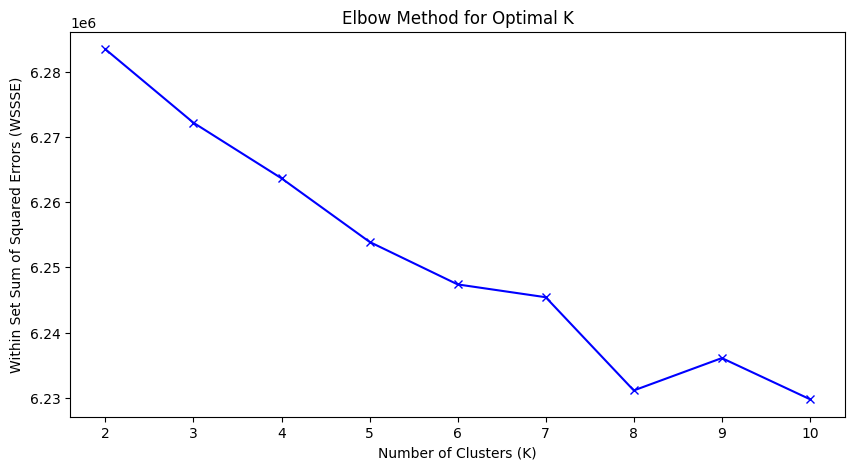

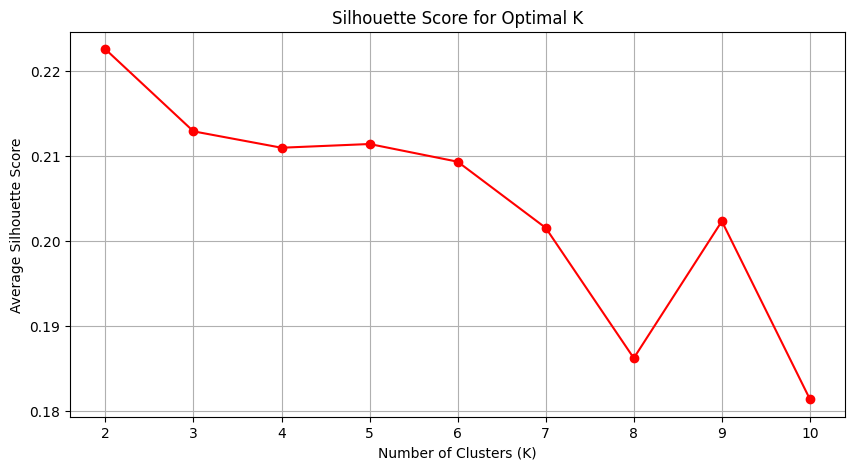

In [6]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# หาจำนวนกลุ่มที่เหมาะสม (K) โดยใช้ PySpark MLlib
sse = []
silhouette_avg = []
k_range = range(2, 11) # ทดสอบที่ 2 ถึง 10 กลุ่ม

# เตรียม evaluator สำหรับ Silhouette score
evaluator = ClusteringEvaluator(featuresCol="tfidf_features",
                               predictionCol="cluster_prediction",
                               metricName="silhouette",
                               distanceMeasure="squaredEuclidean")

for k in k_range:
    # กำหนดค่า KMeans สำหรับ PySpark
    kmeans = KMeans(featuresCol="tfidf_features", k=k, seed=42, predictionCol="cluster_prediction") # เปลี่ยนชื่อคอลัมน์ predictionCol
    model = kmeans.fit(df_tfidf)

    # สำหรับ Elbow Method (SSE)
    wssse = model.summary.trainingCost # Within Set Sum of Squared Errors
    sse.append(wssse)

    # สำหรับ Silhouette Analysis
    predictions = model.transform(df_tfidf)
    silhouette = evaluator.evaluate(predictions)
    silhouette_avg.append(silhouette)

# Plot Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within Set Sum of Squared Errors (WSSSE)')
plt.title('Elbow Method for Optimal K')
plt.show()

# Plot Silhouette Analysis
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_avg, 'ro-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [7]:
from pyspark.ml.clustering import KMeans
import pandas as pd

# ทำ Clustering ด้วย K ที่เลือก
optimal_k = 3
kmeans = KMeans(featuresCol="tfidf_features", k=optimal_k, seed=42, predictionCol="cluster_label")
model = kmeans.fit(df_tfidf)

# Get the predictions as a PySpark DataFrame
df_clustered_spark = model.transform(df_tfidf)

print(f"จำนวนแถวทั้งหมด: {df_clustered_spark.count()} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_clustered_spark.columns)} คอลัมน์")
df_clustered_spark.printSchema()
df_clustered_spark.show(5)

จำนวนแถวทั้งหมด: 37373 แถว
จำนวนคอลัมน์ทั้งหมด: 19 คอลัมน์
root
 |-- body: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- is_submitter: boolean (nullable = true)
 |-- author: string (nullable = true)
 |-- removal_reason: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- score: long (nullable = true)
 |-- ups: long (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- body_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- raw_features: vector (nullable = true)
 |-- tfidf_features: vector (nullable = true)
 |-- cluster_label: integer (nullable = false)

+-----

In [8]:
from pyspark.sql import functions as F

# EDA พื้นฐานแต่ละกลุ่ม โดยใช้ PySpark
cluster_eda_spark = df_clustered_spark.groupBy('cluster_label').agg(
    F.count('row_id').alias('count_rows'),
    F.mean('ups').alias('avg_upvotes')
)

print("Cluster EDA Summary:")
cluster_eda_spark.show()

Cluster EDA Summary:
+-------------+----------+------------------+
|cluster_label|count_rows|       avg_upvotes|
+-------------+----------+------------------+
|            1|      1261| 7.213322759714512|
|            2|       663| 8.447963800904978|
|            0|     35449|5.5852633360602555|
+-------------+----------+------------------+



Proportion of Topics by Cluster (Including Sentiments):
detected_topics  prod_affordable  prod_performance  prod_usability  \
cluster_label                                                        
0                       0.088645          0.024456        0.027581   
1                       0.071283          0.023761        0.038697   
2                       0.049505          0.011881        0.035644   

detected_topics  sentiment_negative  sentiment_positive  usecase_code  \
cluster_label                                                           
0                          0.105710            0.265787      0.152488   
1                          0.059063            0.338764      0.219280   
2                          0.112871            0.251485      0.130693   

detected_topics  usecase_creative  usecase_data  usecase_research  \
cluster_label                                                       
0                        0.092316      0.023364          0.108438   
1                   

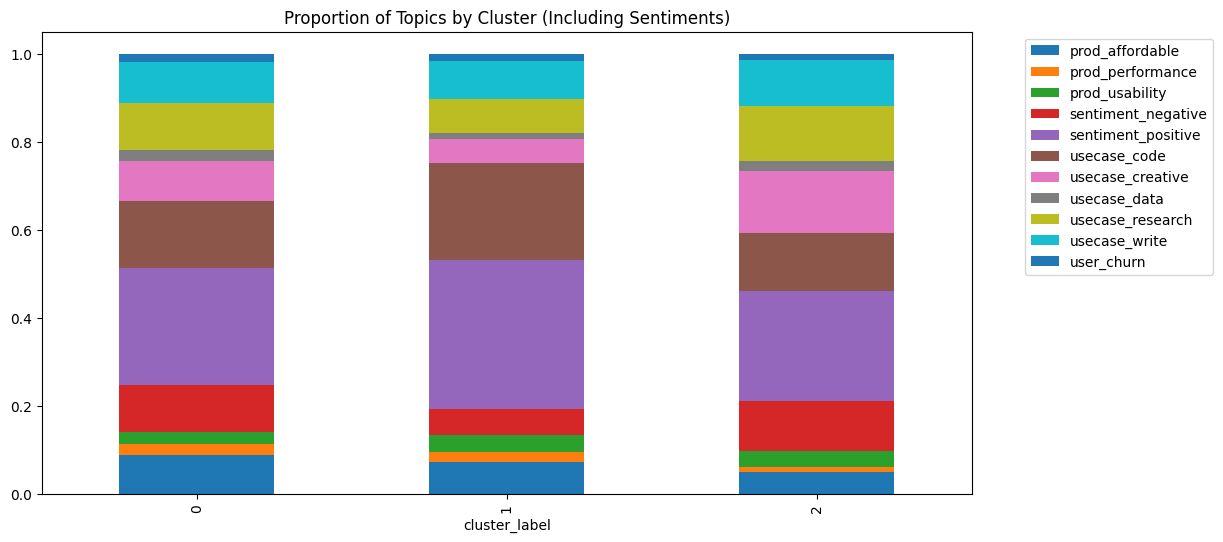

Proportion of each Topic across Clusters (Including Sentiments):
cluster_label              0         1         2
detected_topics                                 
prod_affordable     0.932186  0.054773  0.013041
prod_performance    0.923221  0.065543  0.011236
prod_usability      0.881141  0.090333  0.028526
sentiment_negative  0.936703  0.038242  0.025055
sentiment_positive  0.895388  0.083389  0.021223
usecase_code        0.887670  0.093272  0.019059
usecase_creative    0.924950  0.039761  0.035288
usecase_data        0.934524  0.041667  0.023810
usecase_research    0.925487  0.047841  0.026672
usecase_write       0.912136  0.062136  0.025728
user_churn          0.918987  0.063291  0.017722


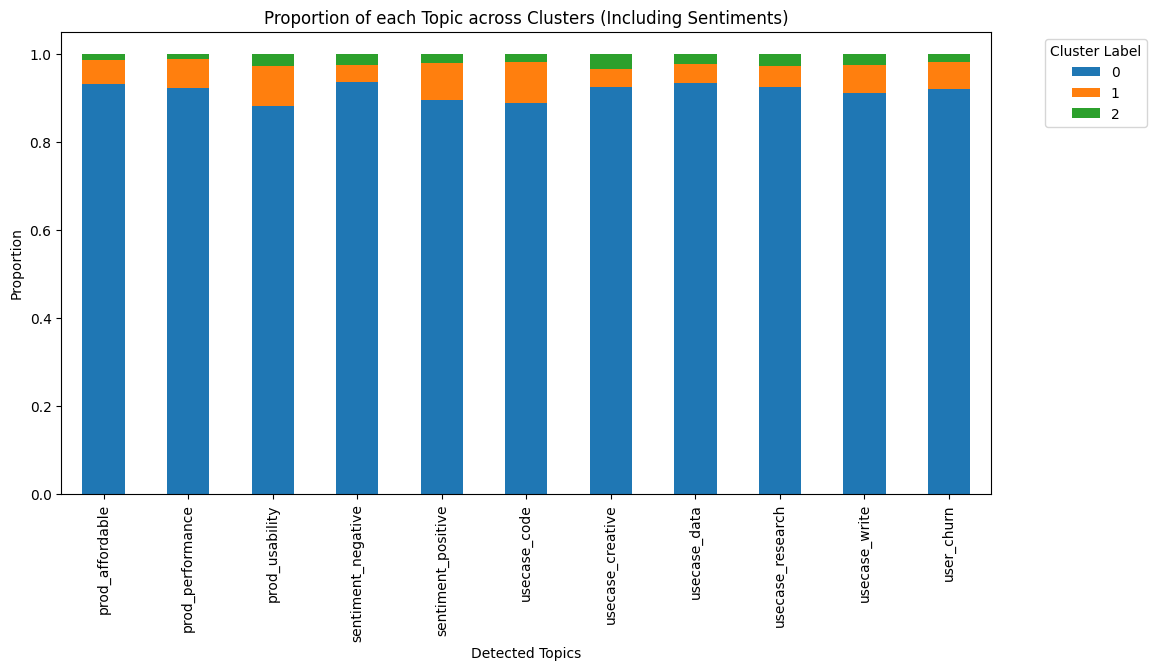

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Convert relevant columns from PySpark DataFrame to Pandas DataFrame for analysis and plotting
df_comments = df_clustered_spark.select('detected_topics', 'cluster_label', 'prediction', 'AI_Name').toPandas()

# สัดส่วนของ Topic ในแต่ละ Cluster
df_exploded = df_comments.explode('detected_topics')

topic_proportion_with_sentiments = pd.crosstab(df_exploded['cluster_label'], df_exploded['detected_topics'], normalize='index')
print("Proportion of Topics by Cluster:")
print(topic_proportion_with_sentiments)

topic_proportion_with_sentiments.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of Topics by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# สัดส่วนของแต่ละ Topic กระจายในแต่ละ Cluster
topic_proportion_swapped_with_sentiments = pd.crosstab(df_exploded['detected_topics'], df_exploded['cluster_label'], normalize='index')
print("Proportion of each Topic across Clusters:")
print(topic_proportion_swapped_with_sentiments)

topic_proportion_swapped_with_sentiments.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of each Topic across Clusters')
plt.xlabel('Detected Topics')
plt.ylabel('Proportion')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Proportion of Topics by Cluster:
detected_topics  prod_affordable  prod_performance  prod_usability  \
cluster_label                                                        
0                       0.141042          0.038911        0.043883   
1                       0.118377          0.039459        0.064262   
2                       0.077882          0.018692        0.056075   

detected_topics  usecase_code  usecase_creative  usecase_data  \
cluster_label                                                   
0                    0.242620          0.146882      0.037174   
1                    0.364149          0.090192      0.023675   
2                    0.205607          0.221184      0.037383   

detected_topics  usecase_research  usecase_write  user_churn  
cluster_label                                                 
0                        0.172534       0.148303    0.028650  
1                        0.127396       0.144307    0.028185  
2                        0.196262     

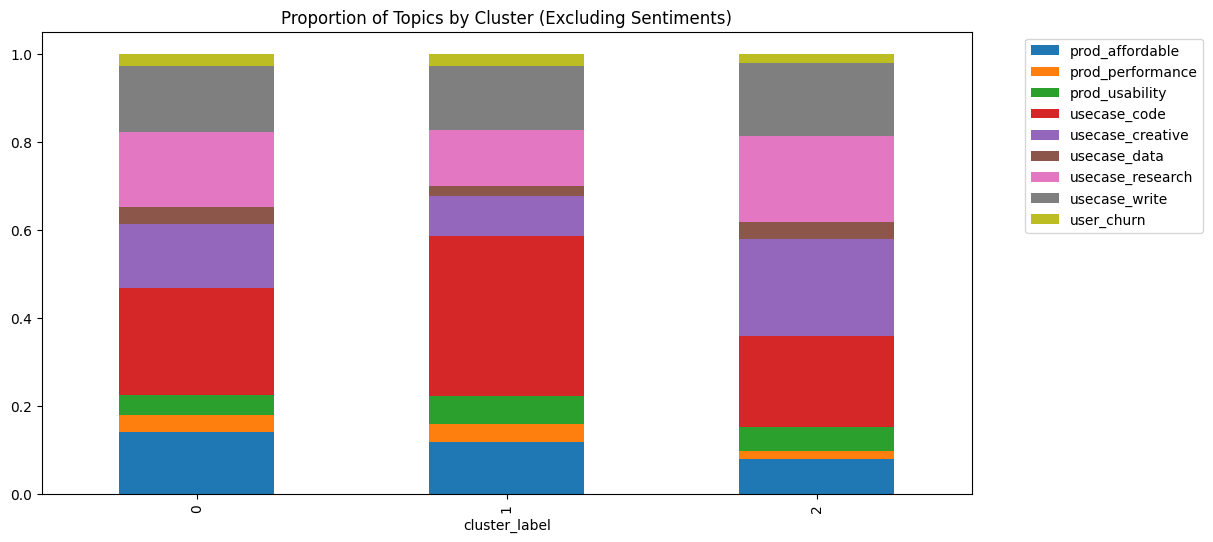

Proportion of each Topic across Clusters (Excluding Sentiments):
cluster_label            0         1         2
detected_topics                               
prod_affordable   0.932186  0.054773  0.013041
prod_performance  0.923221  0.065543  0.011236
prod_usability    0.881141  0.090333  0.028526
usecase_code      0.887670  0.093272  0.019059
usecase_creative  0.924950  0.039761  0.035288
usecase_data      0.934524  0.041667  0.023810
usecase_research  0.925487  0.047841  0.026672
usecase_write     0.912136  0.062136  0.025728
user_churn        0.918987  0.063291  0.017722


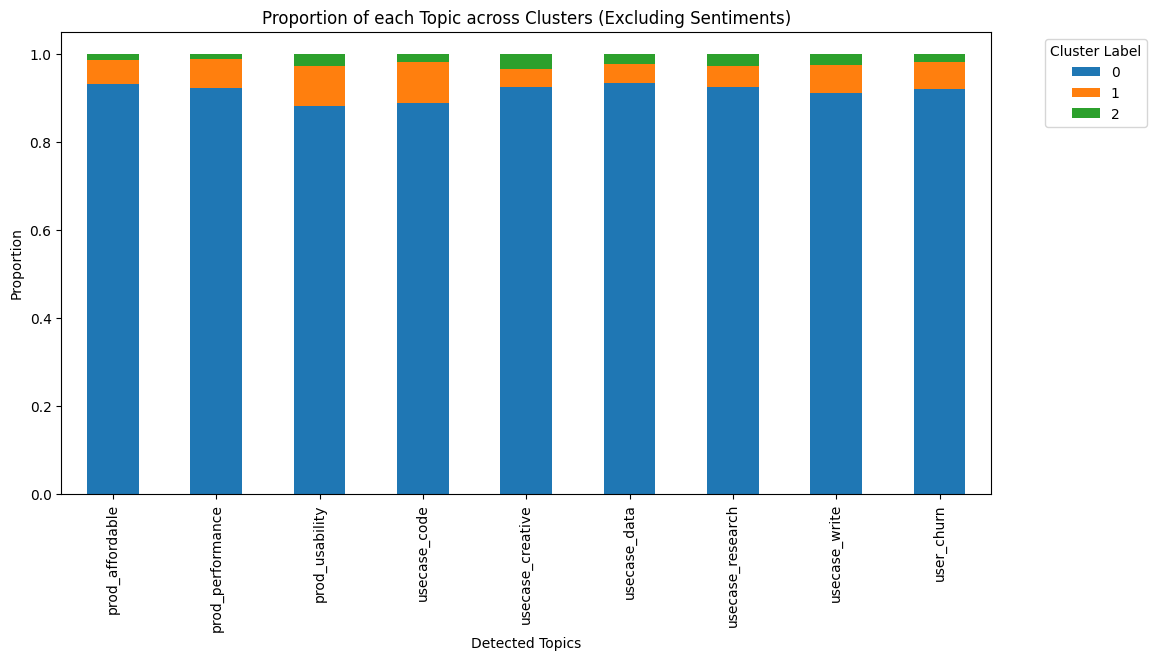

In [12]:
# Filter out 'sentiment_negative' and 'sentiment_positive'
df_exploded_filtered = df_exploded[~df_exploded['detected_topics'].isin(['sentiment_negative', 'sentiment_positive'])]

topic_proportion = pd.crosstab(df_exploded_filtered['cluster_label'], df_exploded_filtered['detected_topics'], normalize='index')
print("Proportion of Topics by Cluster:")
print(topic_proportion)

topic_proportion.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of Topics by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# สัดส่วนของแต่ละ Topic กระจายในแต่ละ Cluster
topic_proportion_swapped = pd.crosstab(df_exploded_filtered['detected_topics'], df_exploded_filtered['cluster_label'], normalize='index')
print("Proportion of each Topic across Clusters:")
print(topic_proportion_swapped)

topic_proportion_swapped.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of each Topic across Clusters')
plt.xlabel('Detected Topics')
plt.ylabel('Proportion')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Proportion of Sentiment by Cluster:
prediction          0.0       1.0       2.0
cluster_label                              
0              0.555079  0.275974  0.168947
1              0.390167  0.275178  0.334655
2              0.389140  0.420814  0.190045


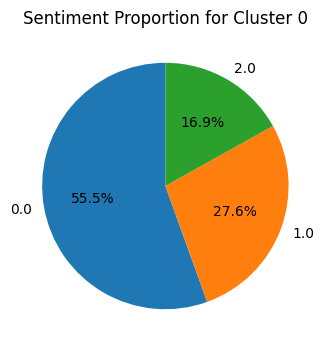

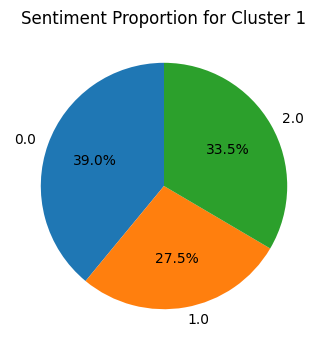

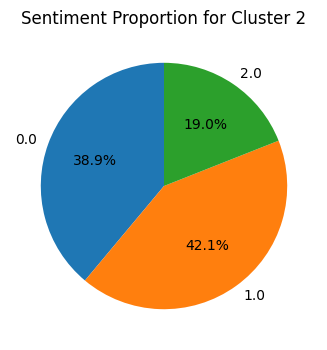

Proportion of each Sentiment across Clusters:
cluster_label         0         1         2
prediction                                 
0.0            0.963284  0.024086  0.012630
1.0            0.939860  0.033337  0.026804
2.0            0.916169  0.064556  0.019275


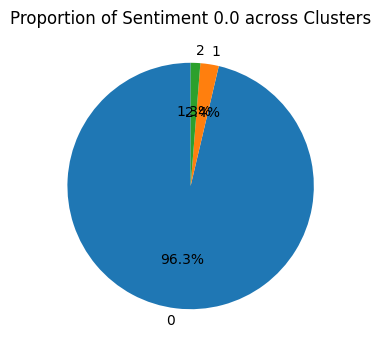

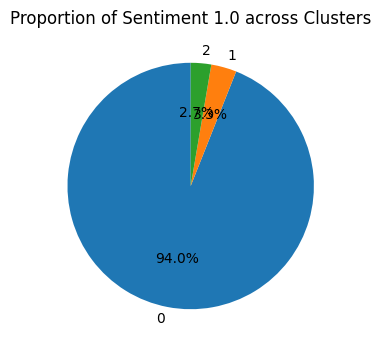

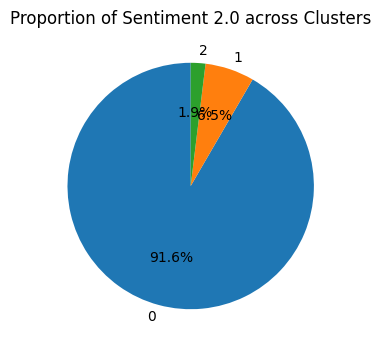

In [14]:
# สัดส่วนของ Sentiment ในแต่ละ Cluster
sentiment_proportion = pd.crosstab(df_comments['cluster_label'], df_comments['prediction'], normalize='index')
print("Proportion of Sentiment by Cluster:")
print(sentiment_proportion)

# Define a colormap for the pie charts
colors = plt.cm.Set3.colors

for cluster_label in sentiment_proportion.index:
    plt.figure(figsize=(8, 4))
    plt.pie(sentiment_proportion.loc[cluster_label], labels=sentiment_proportion.columns, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Sentiment Proportion for Cluster {int(cluster_label)}')
    plt.show()

# สัดส่วนของแต่ละ Sentiment กระจายในแต่ละ Cluster
sentiment_proportion_swapped = pd.crosstab(df_comments['prediction'], df_comments['cluster_label'], normalize='index')
print("Proportion of each Sentiment across Clusters:")
print(sentiment_proportion_swapped)

for sentiment_pred in sentiment_proportion_swapped.index:
    plt.figure(figsize=(8, 4))
    plt.pie(sentiment_proportion_swapped.loc[sentiment_pred], labels=sentiment_proportion_swapped.columns, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Proportion of Sentiment {sentiment_pred} across Clusters')
    plt.show()

Proportion of Product by Cluster:
AI_Name         ChatGPT    Claude  DeepSeek    Gemini      Grok
cluster_label                                                  
0              0.748061  0.091230  0.016898  0.081779  0.062033
1              0.378271  0.533703  0.009516  0.040444  0.038065
2              0.751131  0.110106  0.013575  0.073906  0.051282


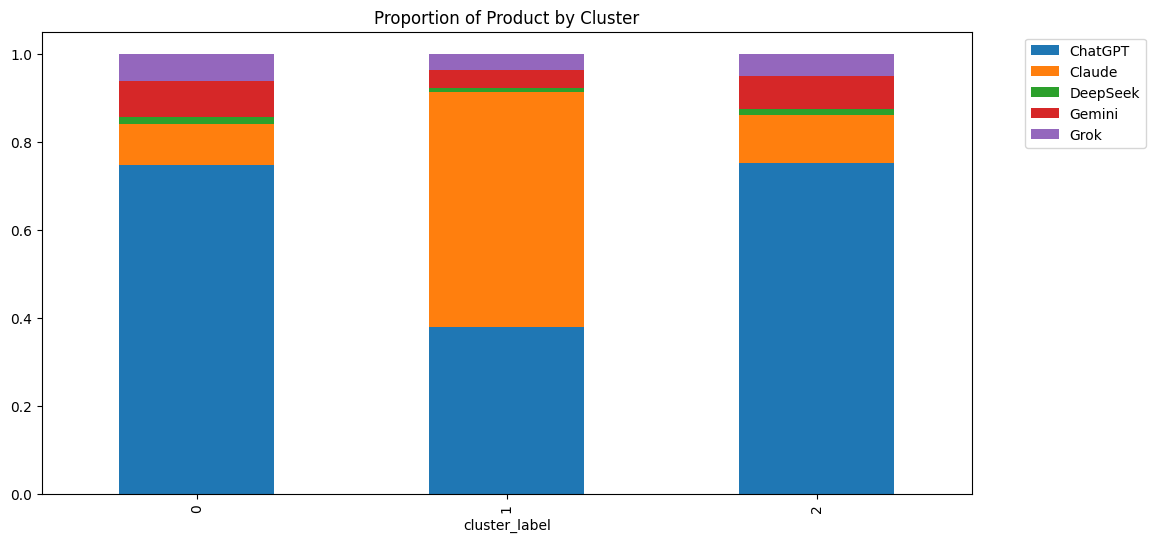

Proportion of each AI Product across Clusters:
cluster_label         0         1         2
AI_Name                                    
ChatGPT        0.964536  0.017350  0.018114
Claude         0.812563  0.169095  0.018342
DeepSeek       0.966129  0.019355  0.014516
Gemini         0.966656  0.017006  0.016339
Grok           0.964051  0.021043  0.014906


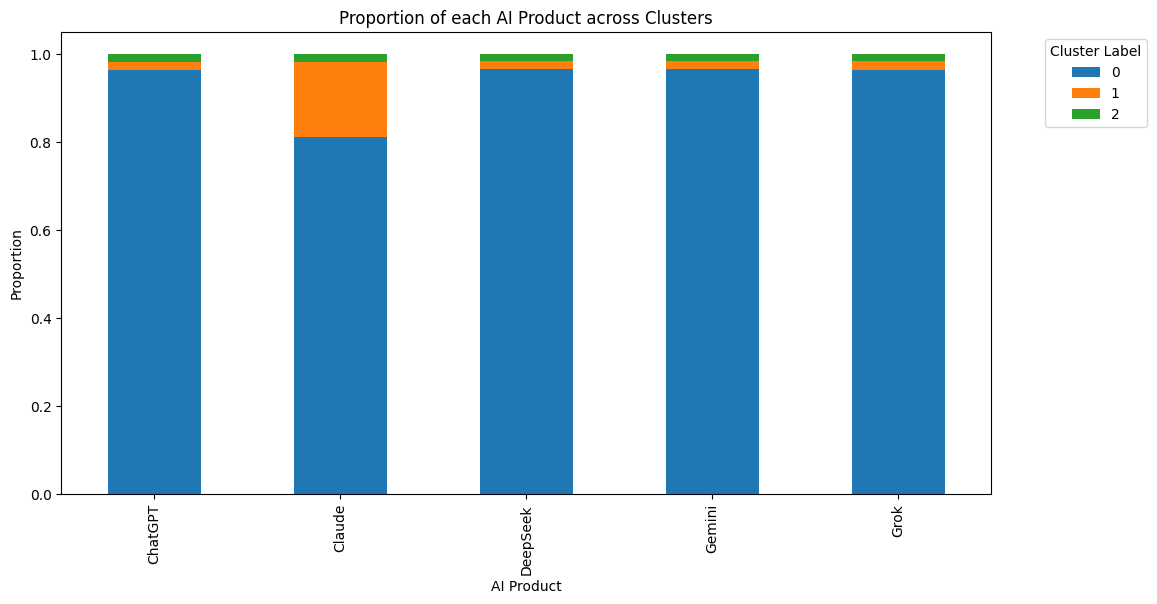

In [15]:
# สัดส่วนของ AI Product ในแต่ละ Cluster
product_proportion = pd.crosstab(df_comments['cluster_label'], df_comments['AI_Name'], normalize='index')
print("Proportion of Product by Cluster:")
print(product_proportion)

product_proportion.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of Product by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# สัดส่วนของแต่ละ AI Product กระจายในแต่ละ Cluster
product_proportion_swapped = pd.crosstab(df_comments['AI_Name'], df_comments['cluster_label'], normalize='index')
print("Proportion of each AI Product across Clusters:")
print(product_proportion_swapped)

product_proportion_swapped.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of each AI Product across Clusters')
plt.xlabel('AI Product')
plt.ylabel('Proportion')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()